# Data Analysis (qubit_TransmonCross_cap_matrix)
## Quantum Metal --> Capacitance

Ansys surrogate model

## Configuration

Disable cell scrolling.

The parameter file is where the hyperparameters are set. It's reccomended to look at that file first, its interesting and you can set stuff there

In [1]:
from pathlib import Path
from parameters_surrogate import *

In [2]:
## make directory for data and scaler saving
os.makedirs('scalers', exist_ok=True)
os.makedirs(f'{DATA_DIR}', exist_ok=True)
os.makedirs(f'{DATA_DIR}/npy', exist_ok=True)

## Library

In [3]:
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

2026-06-05 20:28:27.961730: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Datasets

### Load
From https://huggingface.co/datasets/SQuADDS/SQuADDS_DB/tree/main

In [4]:
df = pd.read_json(str(Path(METADATA_DIR) / "qubit-TransmonCross-EC.json"))

### Look at the data and structure

In [5]:
## look at the first value
first_entry = df.iloc[100]

## print the headers and their corresponding values
for header, value in first_entry.items():
    print(f"{header}: {value}")

sim_results: {'cross_to_ground': 155.21897, 'claw_to_ground': 63.04611, 'cross_to_claw': 1.83606, 'cross_to_cross': 155.21897, 'claw_to_claw': 65.18175, 'ground_to_ground': 279.3005, 'units': 'fF'}
sim_options: {'setup': {'name': 'sweep_setup', 'reuse_selected_design': False, 'reuse_setup': False, 'freq_ghz': 5.0, 'save_fields': False, 'enabled': True, 'max_passes': 30, 'min_passes': 2, 'min_converged_passes': 1, 'percent_error': 0.1, 'percent_refinement': 30, 'auto_increase_solution_order': True, 'solution_order': 'High', 'solver_type': 'Iterative', 'run': {'name': 'sweep_v2.0', 'components': ['Q'], 'open_terminations': [['Q', 'readout']], 'box_plus_buffer': True}}, 'renderer_options': {'Lj': '10nH', 'Cj': 0, '_Rj': 0, 'max_mesh_length_jj': '7um', 'max_mesh_length_port': '7um', 'project_path': None, 'project_name': None, 'design_name': None, 'x_buffer_width_mm': 0.2, 'y_buffer_width_mm': 0.2, 'wb_threshold': '400um', 'wb_offset': '0um', 'wb_size': 5, 'plot_ansys_fields_options': {'nam

In [6]:
## look at the headers relevant for us, to start lets only look at the sim_results (our x data) and design (our y data)
EC_column = df['EC_GHz']
print(EC_column, '\n\n')

design_column = df['design']
print(design_column)

0       0.119465
1       0.101368
2       0.180164
3       0.107663
4       0.157593
          ...   
1929    0.108262
1930    0.099138
1931    0.107729
1932    0.326978
1933    0.300063
Name: EC_GHz, Length: 1934, dtype: float64 


0       {'design_options': {'pos_x': '-1500um', 'pos_y...
1       {'design_options': {'pos_x': '-1500um', 'pos_y...
2       {'design_options': {'pos_x': '-1500um', 'pos_y...
3       {'design_options': {'pos_x': '-1500um', 'pos_y...
4       {'design_options': {'pos_x': '-1500um', 'pos_y...
                              ...                        
1929    {'design_options': {'pos_x': '-1500um', 'pos_y...
1930    {'design_options': {'pos_x': '-1500um', 'pos_y...
1931    {'design_options': {'pos_x': '-1500um', 'pos_y...
1932    {'design_options': {'pos_x': '-1500um', 'pos_y...
1933    {'design_options': {'pos_x': '-1500um', 'pos_y...
Name: design, Length: 1934, dtype: object


In [7]:
## take a look at everything in the design dataset
## flatten the design column
design_flat = json_normalize(df['design'])

## list all column headers
design_column_vals = design_flat.columns.tolist()
print(design_column_vals)
print('length: ',len(design_column_vals))

['design_tool', 'design_options.pos_x', 'design_options.pos_y', 'design_options.orientation', 'design_options.chip', 'design_options.layer', 'design_options.connection_pads.readout.connector_type', 'design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.connection_pads.readout.claw_width', 'design_options.connection_pads.readout.claw_gap', 'design_options.connection_pads.readout.claw_cpw_length', 'design_options.connection_pads.readout.claw_cpw_width', 'design_options.connection_pads.readout.connector_location', 'design_options.cross_width', 'design_options.cross_length', 'design_options.cross_gap', 'design_options.hfss_inductance', 'design_options.hfss_capacitance', 'design_options.hfss_resistance', 'design_options.hfss_mesh_kw_jj', 'design_options.q3d_inductance', 'design_options.q3d_capacitance', 'design_options.q3d_resistance', 'design_options.q3d_mesh_kw_jj', 'design_options.gds_cell_name', 'design_options.aedt

### Reformat

In [8]:
## our Hamiltonian data is now just the single charging energy E_C (Model 1's X, Model 2's Y)
X_cap = df[['EC_GHz']].astype(float)
print(X_cap)

        EC_GHz
0     0.119465
1     0.101368
2     0.180164
3     0.107663
4     0.157593
...        ...
1929  0.108262
1930  0.099138
1931  0.107729
1932  0.326978
1933  0.300063

[1934 rows x 1 columns]


In [9]:
## flatten the qiskit metal design parameters
y_design = json_normalize(df['design'])

columns_to_drop = ['design_tool', 'design_options.pos_x', 'design_options.pos_y',
       'design_options.orientation', 'design_options.chip',
       'design_options.layer',
       'design_options.connection_pads.readout.connector_type',
       'design_options.connection_pads.readout.claw_width',
       'design_options.connection_pads.readout.claw_gap',
       'design_options.connection_pads.readout.claw_cpw_length',
       'design_options.connection_pads.readout.claw_cpw_width',
       'design_options.connection_pads.readout.connector_location',
       'design_options.cross_width',
       'design_options.cross_gap', 'design_options.hfss_inductance',
       'design_options.hfss_capacitance', 'design_options.hfss_resistance',
       'design_options.hfss_mesh_kw_jj', 'design_options.q3d_inductance',
       'design_options.q3d_capacitance', 'design_options.q3d_resistance',
       'design_options.q3d_mesh_kw_jj', 'design_options.gds_cell_name',
       'design_options.aedt_q3d_inductance',
       'design_options.aedt_q3d_capacitance',
       'design_options.aedt_hfss_inductance',
       'design_options.aedt_hfss_capacitance']

## get rid of this column because there are two spellings in the dataset that will confuse the NN.
## we always just use qiskit, so for now we don't need this
y_design = y_design.drop(columns=columns_to_drop)

print(f'y_design shape: {y_design.shape}')
print(y_design)

y_design shape: (1934, 3)
     design_options.connection_pads.readout.claw_length  \
0                                                 160um   
1                                                 120um   
2                                                 130um   
3                                                 180um   
4                                                  90um   
...                                                 ...   
1929                                              190um   
1930                                              240um   
1931                                              280um   
1932                                               90um   
1933                                               70um   

     design_options.connection_pads.readout.ground_spacing  \
0                                                  10um      
1                                                 9.1um      
2                                                  10um      
3                

### Validate and View Data

In [10]:
display(X_cap)

,EC_GHz
0,0.119465
1,0.101368
2,0.180164
3,0.107663
4,0.157593
...,...
1929,0.108262
1930,0.099138
1931,0.107729
1932,0.326978


In [11]:
display(y_design)

,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
0,160um,10um,310um
1,120um,9.1um,350um
2,130um,10um,210um
3,180um,5um,330um
4,90um,5um,230um
...,...,...,...
1929,190um,10um,340um
1930,240um,4.1um,370um
1931,280um,9.1um,330um
1932,90um,10um,120um


## Transform Y to Numerical Values

We need all columns to be numeric floats for the MLP. This means stripping units like 'um' and 'nH',
converting to SI, and filling NaNs.

In [12]:
## look at the format all of the y values are in
for col in y_design.columns:
    print(f"{col}  {y_design[col].iloc[0]}")
print(y_design.shape)

design_options.connection_pads.readout.claw_length  160um
design_options.connection_pads.readout.ground_spacing  10um
design_options.cross_length  310um
(1934, 3)


In [13]:
y_numerical = y_design.copy()

In [14]:
## strip units (um, nH) and convert to SI
y_numerical_clean = y_numerical.copy()

## extract numerical values and convert units (assuming 'um' for some columns)
um_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('um').any()]

for col in um_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('um', '', regex=False), errors='coerce') * 1e-6
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

nH_cols = [col for col in y_numerical_clean.columns if y_numerical_clean[col].astype(str).str.contains('nH').any()]
for col in nH_cols:
    y_numerical_clean[col] = pd.to_numeric(y_numerical_clean[col].astype(str).str.replace('nH', '', regex=False), errors='coerce') * 1e-9
    y_numerical_clean[col] = y_numerical_clean[col].round(15)

for col in y_numerical_clean.columns:
    try:
        print(f"{col}-----------Numerical: {y_numerical_clean[col].iloc[0]}-----------Original: {y_design[col].iloc[0]}")
    except KeyError:
        print(f'{col} -- changed')

design_options.connection_pads.readout.claw_length-----------Numerical: 0.00016-----------Original: 160um
design_options.connection_pads.readout.ground_spacing-----------Numerical: 1e-05-----------Original: 10um
design_options.cross_length-----------Numerical: 0.00031-----------Original: 310um


In [15]:
## print how many columns have nan in them
for col in y_design.columns:
    total = len(y_design[col])
    n_nan = y_design[col].isna().sum()
    if 0 < n_nan < total:
        pct_nan = n_nan / total * 100
        zero_mask = y_design[col].astype(str).str.contains('0.0', na=False)
        n_zero = zero_mask.sum()
        pct_zero = n_zero / total * 100
        print(f"{col}:")
        print(f"  NaN values:  {n_nan}/{total}  ({pct_nan:.2f}%)")
        print(f"  '0.0' vals:  {n_zero}/{total}  ({pct_zero:.2f}%)")
        print()

In [16]:
## fill nan with 1 (same as original notebook)
y_numerical_clean.fillna(float(1), inplace=True)

print('Now all of these should be numerical:')
for col in y_numerical_clean.columns:
    print(f"{col}-----------{y_numerical_clean[col].iloc[0]}")

Now all of these should be numerical:
design_options.connection_pads.readout.claw_length-----------0.00016
design_options.connection_pads.readout.ground_spacing-----------1e-05
design_options.cross_length-----------0.00031


In [17]:
y_final = y_numerical_clean.copy()
print('Final y shape:', y_final.shape)
display(y_final)

Final y shape: (1934, 3)


,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
0,0.00016,0.000010,0.00031
1,0.00012,0.000009,0.00035
2,0.00013,0.000010,0.00021
3,0.00018,0.000005,0.00033
4,0.00009,0.000005,0.00023
...,...,...,...
1929,0.00019,0.000010,0.00034
1930,0.00024,0.000004,0.00037
1931,0.00028,0.000009,0.00033
1932,0.00009,0.000010,0.00012


### Save the header names of the y data

In [18]:
filename = str(Path(METADATA_DIR) / 'y_characteristics_linear_encoding.csv')
headers = list(y_final.columns)
with open(filename, 'w') as f:
    f.write(','.join(headers))
print(f'Saved {filename} with {len(headers)} columns')

Saved /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/metadata/y_characteristics_linear_encoding.csv with 3 columns


## Visualize

### X Data (Hamiltonian parameters)

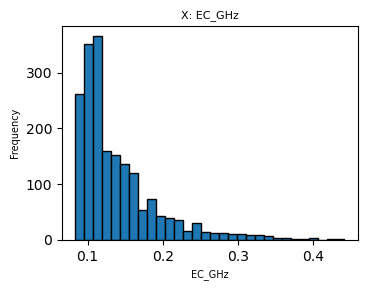

In [19]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_cap.columns):
    axes[i].hist(X_cap[col], bins=30, edgecolor='black')
    axes[i].set_title(f'X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_x_cap_distribution.pdf'))
plt.show()

### Y Data (Quantum Metal params)

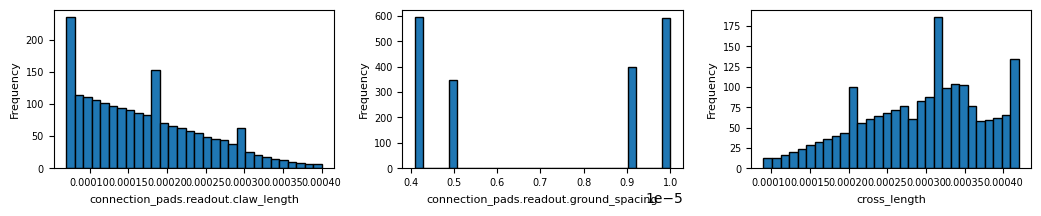

In [20]:
num_cols = len(y_final.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_final.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_final[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_unscaled_y_design_distribution.png'))
plt.show()

In [21]:
plt.close()

## Split

Dataset split is 70%-15%-15% training-validation-test. We use a constant state (seed) for reproducible splits.

In [22]:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_cap, y_final, test_size=0.3, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42, shuffle=True
)

In [23]:
total = y_train.shape[0] + y_test.shape[0] + y_val.shape[0]
print('---------------------------------------')
print('Train set shape: {}, {:.2f}%'.format(y_train.shape, (y_train.shape[0]*100.)/total))
print('Validation set shape: {}, {:.2f}%'.format(y_val.shape, (y_val.shape[0]*100.)/total))
print('Test set shape: {}, {:.2f}%'.format(y_test.shape, (y_test.shape[0]*100.)/total))
print('---------------------------------------')

---------------------------------------
Train set shape: (1353, 3), 69.96%
Validation set shape: (290, 3), 14.99%
Test set shape: (291, 3), 15.05%
---------------------------------------


## Augment

### Scale X (Hamiltonian Parameters)

Scale capacitance values to be between 0 and 1

In [24]:
def scale_splits_per_column(train_df, val_df, test_df, scaler_name_prefix):
    train_s = train_df.copy()
    val_s   = val_df.copy()
    test_s  = test_df.copy()

    scalers = {}
    for col in train_df.columns:
        sc = MinMaxScaler()
        sc.fit(train_df[[col]])

        train_s[col] = sc.transform(train_df[[col]])
        val_s[col]   = sc.transform(val_df[[col]])
        test_s[col]  = sc.transform(test_df[[col]])

        scalers[col] = sc
        joblib.dump(sc, f'{SCALERS_DIR}/{scaler_name_prefix}_{col}.save')

    return train_s, val_s, test_s, scalers

X_train_scaled, X_val_scaled, X_test_scaled, x_scalers = scale_splits_per_column(
    X_train, X_val, X_test,
    scaler_name_prefix='scaler_X_linear'
)

In [25]:
## look at the scaled stuff to check
display(X_train_scaled.head())
display(X_val_scaled.head())
display(X_test_scaled.head())

,EC_GHz
745,0.045413
1442,0.013645
937,0.130635
493,0.051877
1271,0.320126


,EC_GHz
1856,0.104546
832,0.080863
1393,0.103214
483,0.238576
1023,0.158973


,EC_GHz
1547,0.161252
1890,0.130132
1009,0.376330
613,0.263593
715,0.433493


### Scale Y (Quantum Metal params)

In [26]:
y_train_scaled, y_val_scaled, y_test_scaled, y_scalers = scale_splits_per_column(
    y_train, y_val, y_test,
    scaler_name_prefix='scaler_y_linear'
)

In [27]:
## look at the scaled stuff to check
display(y_train_scaled.head())
display(y_val_scaled.head())
display(y_test_scaled.head())

,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
745,0.181818,0.000000,0.848485
1442,0.060606,1.000000,0.939394
937,0.030303,0.847458,0.575758
493,0.090909,0.847458,0.787879
1271,0.000000,0.152542,0.303030


,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
1856,0.606061,0.000000,0.666667
832,0.696970,0.152542,0.696970
1393,0.121212,0.847458,0.636364
483,0.060606,0.152542,0.393939
1023,0.454545,0.000000,0.545455


,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
1547,0.333333,0.152542,0.515152
1890,0.090909,1.000000,0.606061
1009,0.121212,0.000000,0.272727
613,0.181818,0.152542,0.363636
715,0.060606,0.152542,0.212121


### Plot Scaled Data

### X

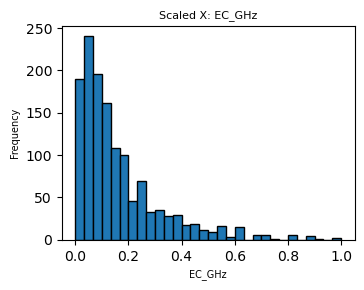

In [28]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_train_scaled.columns):
    axes[i].hist(X_train_scaled[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Scaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_scaled_x_cap_distribution.pdf'))
plt.show()

### Y

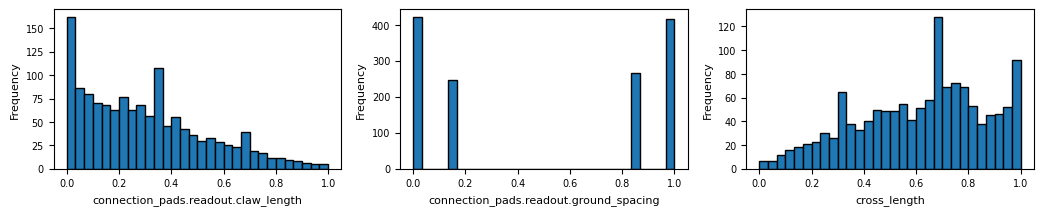

In [29]:
num_cols = len(y_train_scaled.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for n, col in enumerate(y_train_scaled.columns):
    try:
        plt.subplot(num_rows, 4, n + 1)
        plt.hist(y_train_scaled[col], bins=30, edgecolor='black')
        plt.xlabel(col.split('design_options.')[-1], fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.tick_params(axis='both', which='major', labelsize=7)
    except TypeError:
        print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")

plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_scaled_y_design_distribution.png'))
plt.show()

In [30]:
plt.close()

## Unscaling

To make sure we can recreate original values with saved scaler (compare with above cells)

### Unscale X

In [31]:
X_check = X_train_scaled
prefix = 'scaler_X_linear'

X_orig = X_check.copy()
for col in X_check.columns:
    sc = joblib.load(f'{SCALERS_DIR}/{prefix}_{col}.save')
    X_orig[col] = sc.inverse_transform(X_check[[col]])

display(X_orig.head())

,EC_GHz
745,0.099151
1442,0.088263
937,0.128358
493,0.101366
1271,0.193300


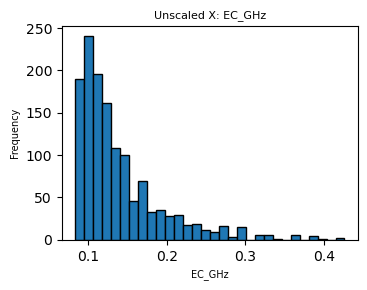

In [32]:
num_cols = len(X_cap.columns)
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i, col in enumerate(X_orig.columns):
    axes[i].hist(X_orig[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Unscaled X: {col}', fontsize=8)
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_unscaled_x_check.pdf'))
plt.show()

### Unscale Y

In [33]:
prefix = 'scaler_y_linear'
y_orig = y_train_scaled.copy()

for col in y_train_scaled.columns:
    sc = joblib.load(f'{SCALERS_DIR}/{prefix}_{col}.save')
    y_orig[col] = sc.inverse_transform(y_train_scaled[[col]])

display(y_orig.head())

,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length
745,0.00013,0.000004,0.00037
1442,0.00009,0.000010,0.00040
937,0.00008,0.000009,0.00028
493,0.00010,0.000009,0.00035
1271,0.00007,0.000005,0.00019


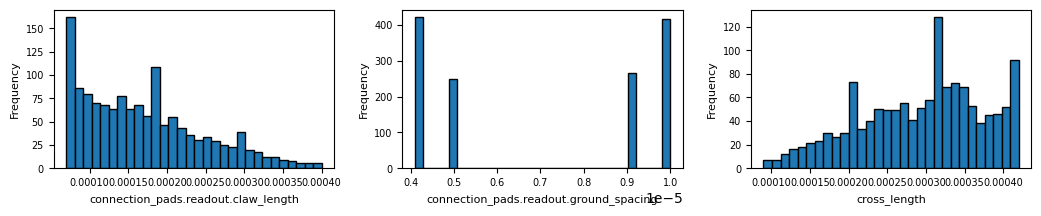

In [34]:
num_cols = len(y_orig.columns)
num_rows = ((num_cols + 2) // 4) + 1

plt.figure(figsize=(14, 2 * num_rows))

for j, col in enumerate(y_orig.columns):
    plt.subplot(num_rows, 4, j + 1)
    plt.hist(y_orig[col], bins=30, edgecolor='black')
    plt.xlabel(col.split('design_options.')[-1], fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)

plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'model2_unscaled_y_check.png'))
plt.show()

## Save

In [35]:
!rm -f $DATA_DIR/npy/*npy

In [36]:
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding.npy', X_train)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding.npy', X_val)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding.npy', X_test)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding.npy', y_train)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding.npy', y_val)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding.npy', y_test)

print(f'Unscaled data saved in: {DATA_DIR}/npy')

Unscaled data saved in: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy


In [37]:
np.save(f'{DATA_DIR}/npy/x_train_linear_encoding_scaled.npy', X_train_scaled)
np.save(f'{DATA_DIR}/npy/x_val_linear_encoding_scaled.npy',   X_val_scaled)
np.save(f'{DATA_DIR}/npy/x_test_linear_encoding_scaled.npy',  X_test_scaled)

np.save(f'{DATA_DIR}/npy/y_train_linear_encoding_scaled.npy', y_train_scaled)
np.save(f'{DATA_DIR}/npy/y_val_linear_encoding_scaled.npy',   y_val_scaled)
np.save(f'{DATA_DIR}/npy/y_test_linear_encoding_scaled.npy',  y_test_scaled)

print(f'Scaled data saved in: {DATA_DIR}/npy')

Scaled data saved in: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy


In [38]:
!ls $DATA_DIR/npy/*npy

/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/x_test_linear_encoding.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/x_test_linear_encoding_scaled.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/x_train_linear_encoding.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/x_train_linear_encoding_scaled.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/x_val_linear_encoding.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/x_val_linear_encoding_scaled.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data/npy/y_test_linear_encoding.npy
/home/olivias/ML_qubit_design/experiments/model_predict_qubit_

In [39]:
## saving column names (where capacitance=metadata/X_names, qiskit params=y_columns)
with open(str(Path(METADATA_DIR) / 'X_names'), 'w') as f:
    f.write('\n'.join(X_cap.columns))

np.save(str(Path(METADATA_DIR) / 'y_columns.npy'), np.array(y_train.columns))
print(f'Saved metadata/X_names ({len(X_cap.columns)} cols) and metadata/y_columns.npy ({len(y_train.columns)} cols)')

Saved metadata/X_names (1 cols) and metadata/y_columns.npy (3 cols)
